# TP1 : Traitement d'images et compression JPEG
**Codage et sécurisation des données visuelles** — ISI, 2025-2026

Environnement : `multimedia312` (Python 3.12, NumPy, OpenCV, Matplotlib, Pillow).
Aucun GPU n'est nécessaire pour ce TP.

## 0. Imports et configuration

In [1]:
import os
import urllib.request

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

# Dossier de travail : images d'entrée et résultats
DATA_DIR = "."          # mettre kodim05.png et kodim15.png ici
OUT_DIR = "resultats_tp1"
os.makedirs(OUT_DIR, exist_ok=True)

print("NumPy  :", np.__version__)
print("OpenCV :", cv2.__version__)
print("Pillow :", Image.__version__)

NumPy  : 1.26.4
OpenCV : 5.0.0
Pillow : 12.0.0


### Récupération des images Kodak
Si `kodim05.png` / `kodim15.png` ne sont pas déjà dans le dossier, la cellule essaie de les télécharger.
Sinon, copiez-les à la main à côté du notebook.

In [2]:
KODAK_URL = "https://r0k.us/graphics/kodak/kodak/{}"

for name in ["kodim05.png", "kodim15.png"]:
    path = os.path.join(DATA_DIR, name)
    if os.path.exists(path):
        print(f"OK       : {name} déjà présent")
        continue
    try:
        urllib.request.urlretrieve(KODAK_URL.format(name), path)
        print(f"Téléchargé : {name}")
    except Exception as e:
        print(f"ECHEC    : {name} ({e}) -> copiez le fichier manuellement dans {os.path.abspath(DATA_DIR)}")

OK       : kodim05.png déjà présent
OK       : kodim15.png déjà présent


## II. Manipulation des images
### 2.1 Lecture d'une image

In [3]:
img = mpimg.imread(os.path.join(DATA_DIR, "kodim05.png"))
print("dtype brut :", img.dtype)

# mpimg.imread renvoie des float32 dans [0, 1] pour un PNG -> conversion en uint8
if img.dtype == np.float32:
    img = (img * 255).round().astype(np.uint8)

print("shape :", img.shape)   # (lignes, colonnes, 3)
print("dtype :", img.dtype)

# Séparation des trois couches
rouge = img[:, :, 0]
vert  = img[:, :, 1]
bleu  = img[:, :, 2]

print("Pixel (ligne=100, colonne=120) :", img[100, 120])
print("Pixel couche rouge             :", rouge[100, 120])

dtype brut : float32
shape : (512, 768, 3)
dtype : uint8
Pixel (ligne=100, colonne=120) : [200 212 172]
Pixel couche rouge             : 200


### 2.2 Affichage de l'image

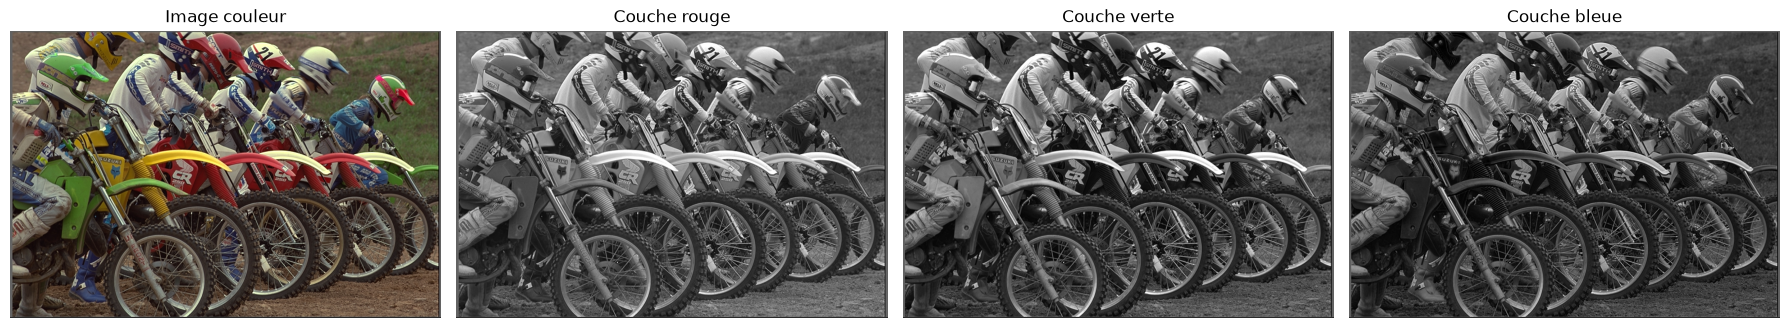

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img);                          axes[0].set_title("Image couleur")
axes[1].imshow(rouge, cmap="gray");           axes[1].set_title("Couche rouge")
axes[2].imshow(vert,  cmap="gray");           axes[2].set_title("Couche verte")
axes[3].imshow(bleu,  cmap="gray");           axes[3].set_title("Couche bleue")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Modifier un pixel.** Les valeurs d'un `uint8` doivent rester dans [0, 255]
(le polycopié utilise 355, ce qui est invalide : on met 255).

In [6]:
img_mod = img.copy()
img_mod[100, 120] = (56, 120, 255)
print("Avant :", img[100, 120], "-> Après :", img_mod[100, 120])

Avant : [200 212 172] -> Après : [ 56 120 255]


**Filtre rouge** : version avec boucles (celle du TP), puis version vectorisée NumPy.

Résultats identiques : True


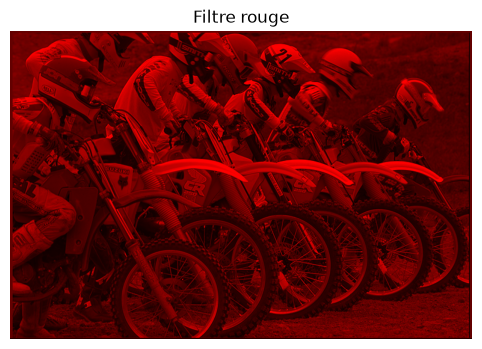

In [7]:
def filtre_rouge(img):
    im = np.copy(img)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r, v, b = im[i, j]
            im[i, j] = (r, 0, 0)
    return im

def filtre_rouge_vec(img):
    im = np.copy(img)
    im[:, :, 1:] = 0          # annule vert et bleu
    return im

im_rouge = filtre_rouge(img)
im_rouge_vec = filtre_rouge_vec(img)
print("Résultats identiques :", np.array_equal(im_rouge, im_rouge_vec))

plt.figure(figsize=(6, 4))
plt.imshow(im_rouge)
plt.axis("off")
plt.title("Filtre rouge")
plt.show()

### 2.3 Sauvegarde des images

In [8]:
mpimg.imsave(os.path.join(OUT_DIR, "monimage.png"), img)
mpimg.imsave(os.path.join(OUT_DIR, "image_filtre_rouge.png"), im_rouge)
print("Fichiers enregistrés dans", os.path.abspath(OUT_DIR))

Fichiers enregistrés dans /home/primaryos/Projects/image-coding/resultats_tp1


### 2.4 Étude statistique des niveaux de gris

Moyenne    : 0.35883686
Ecart-type : 0.19242881


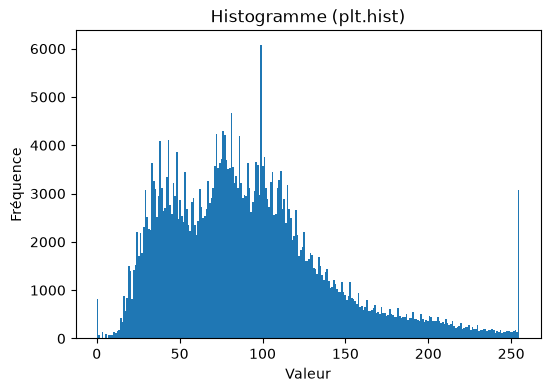

In [9]:
# Sur la couche rouge normalisée dans [0, 1], comme dans le polycopié
rouge_f = rouge.astype(np.float32) / 255.0
print("Moyenne    :", rouge_f.mean())
print("Ecart-type :", rouge_f.std())

plt.figure(figsize=(6, 4))
plt.hist(rouge.ravel(), bins=256, range=(0, 255))
plt.title("Histogramme (plt.hist)")
plt.xlabel("Valeur")
plt.ylabel("Fréquence")
plt.show()

Identique à np.bincount : True


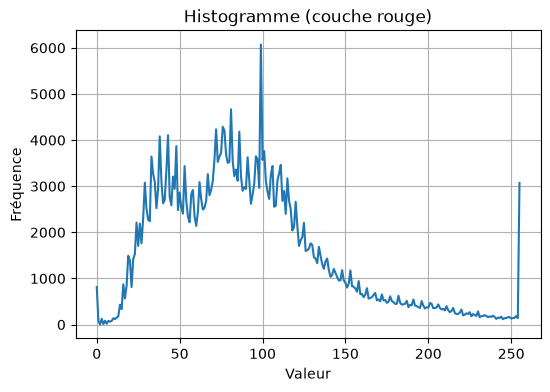

In [10]:
# Histogramme "à la main" : pour chaque valeur 0..255, nombre de pixels
def histogramme(image):
    h = np.zeros(256, dtype=np.float32)
    for j in range(image.shape[0]):
        for i in range(image.shape[1]):
            h[int(image[j, i])] += 1      # image déjà en uint8 (0..255)
    return h

h = histogramme(rouge)
h_np = np.bincount(rouge.ravel(), minlength=256)    # version vectorisée
print("Identique à np.bincount :", np.array_equal(h, h_np))

plt.figure(figsize=(6, 4))
plt.plot(h)
plt.title("Histogramme (couche rouge)")
plt.xlabel("Valeur")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

## III. Conversion couleur → niveaux de gris
$$Niv\_gris = 0.299\,R + 0.587\,V + 0.114\,B$$

Max écart boucles vs vectorisé : 1


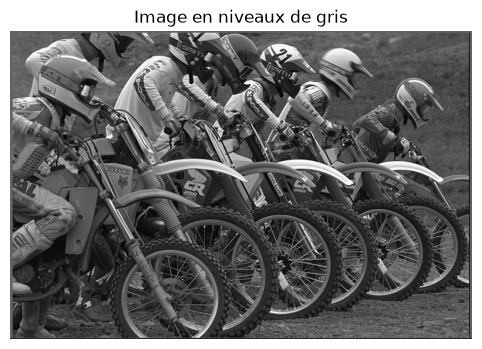

In [11]:
def conversion_gray(img):
    # Version avec boucles (celle du TP), renvoie une image 2D uint8
    gray = np.zeros(img.shape[:2], dtype=np.uint8)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            r, v, b = img[i, j].astype(np.float32)
            gray[i, j] = int(round(0.299 * r + 0.587 * v + 0.114 * b))
    return gray

def conversion_gray_vec(img):
    f = img.astype(np.float32)
    g = 0.299 * f[:, :, 0] + 0.587 * f[:, :, 1] + 0.114 * f[:, :, 2]
    return np.clip(np.round(g), 0, 255).astype(np.uint8)

im_gray = conversion_gray(img)
im_gray_vec = conversion_gray_vec(img)
print("Max écart boucles vs vectorisé :", np.abs(im_gray.astype(int) - im_gray_vec.astype(int)).max())

plt.figure(figsize=(6, 4))
plt.imshow(im_gray, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("Image en niveaux de gris")
plt.show()

## IV. Compression JPEG (Pillow)
Pour chaque facteur de qualité, on compresse en JPEG puis on mesure :
- le **débit** (bpp) = taille du fichier en bits / nombre de pixels ;
- le **PSNR** (dB) entre l'image originale et l'image décompressée.

In [12]:
QUALITIES = [5, 25, 50, 75, 100]

def psnr(a, b):
    # PSNR sur des images uint8 (valeur max = 255)
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")
    return 10 * np.log10(255.0 ** 2 / mse)

def evaluer_jpeg(nom_image, qualities=QUALITIES, gray=False, prefix="resultat"):
    chemin = os.path.join(DATA_DIR, nom_image)
    original = Image.open(chemin).convert("L" if gray else "RGB")
    width, height = original.size
    num_pixels = width * height
    ref = np.array(original)

    bitrates, psnrs = [], []
    for q in qualities:
        out_path = os.path.join(OUT_DIR, f"{prefix}_{os.path.splitext(nom_image)[0]}_q{q}.jpg")
        original.save(out_path, "JPEG", quality=q)

        # Débit
        size_bits = os.path.getsize(out_path) * 8
        bpp = size_bits / num_pixels

        # PSNR : on relit le JPEG décodé
        decoded = np.array(Image.open(out_path).convert("L" if gray else "RGB"))
        p = psnr(ref, decoded)

        bitrates.append(bpp)
        psnrs.append(p)
        print(f"{nom_image} | q={q:3d} -> Bitrate = {bpp:.4f} bpp - PSNR = {p:.2f} dB")
    return bitrates, psnrs

### 4.1 kodim05.png

In [13]:
bitrates1, psnr_values1 = evaluer_jpeg("kodim05.png")

kodim05.png | q=  5 -> Bitrate = 0.3106 bpp - PSNR = 21.41 dB
kodim05.png | q= 25 -> Bitrate = 0.9228 bpp - PSNR = 27.08 dB
kodim05.png | q= 50 -> Bitrate = 1.4054 bpp - PSNR = 29.59 dB
kodim05.png | q= 75 -> Bitrate = 2.0558 bpp - PSNR = 32.31 dB
kodim05.png | q=100 -> Bitrate = 8.3607 bpp - PSNR = 43.21 dB


### 4.2 kodim15.png

In [14]:
bitrates2, psnr_values2 = evaluer_jpeg("kodim15.png")

kodim15.png | q=  5 -> Bitrate = 0.1945 bpp - PSNR = 24.70 dB
kodim15.png | q= 25 -> Bitrate = 0.4454 bpp - PSNR = 30.96 dB
kodim15.png | q= 50 -> Bitrate = 0.6911 bpp - PSNR = 33.07 dB
kodim15.png | q= 75 -> Bitrate = 1.0629 bpp - PSNR = 35.26 dB
kodim15.png | q=100 -> Bitrate = 5.9810 bpp - PSNR = 44.37 dB


### 4.3 Courbes Débit-PSNR

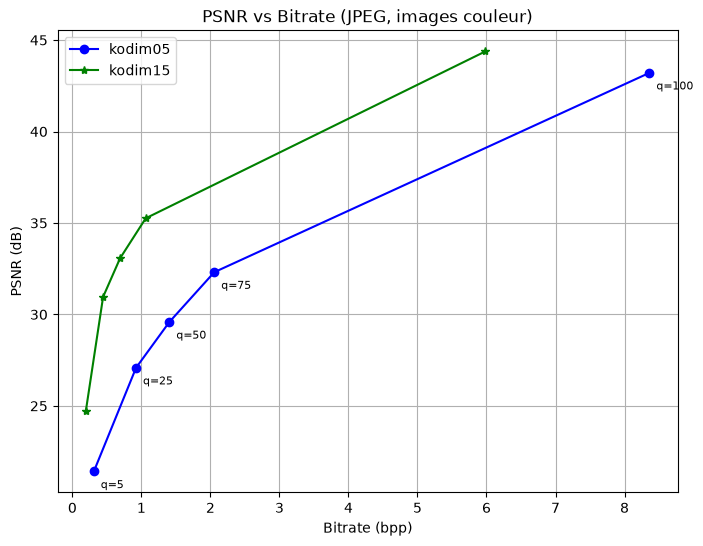

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(bitrates1, psnr_values1, marker="o", linestyle="-", color="blue",  label="kodim05")
plt.plot(bitrates2, psnr_values2, marker="*", linestyle="-", color="green", label="kodim15")
for q, x, y in zip(QUALITIES, bitrates1, psnr_values1):
    plt.annotate(f"q={q}", (x, y), textcoords="offset points", xytext=(5, -12), fontsize=8)
plt.title("PSNR vs Bitrate (JPEG, images couleur)")
plt.xlabel("Bitrate (bpp)")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "bitrate_PSNR.png"), dpi=150)
plt.show()

### 4.4 (Optionnel) Même étude en niveaux de gris
L'introduction du TP demande aussi d'évaluer le codeur sur des images en niveaux de gris.

kodim05.png | q=  5 -> Bitrate = 0.2684 bpp - PSNR = 22.61 dB
kodim05.png | q= 25 -> Bitrate = 0.8485 bpp - PSNR = 28.07 dB
kodim05.png | q= 50 -> Bitrate = 1.2897 bpp - PSNR = 30.70 dB
kodim05.png | q= 75 -> Bitrate = 1.8732 bpp - PSNR = 33.82 dB
kodim05.png | q=100 -> Bitrate = 6.5872 bpp - PSNR = 58.47 dB
kodim15.png | q=  5 -> Bitrate = 0.1532 bpp - PSNR = 27.19 dB
kodim15.png | q= 25 -> Bitrate = 0.3849 bpp - PSNR = 32.64 dB
kodim15.png | q= 50 -> Bitrate = 0.6065 bpp - PSNR = 34.82 dB
kodim15.png | q= 75 -> Bitrate = 0.9387 bpp - PSNR = 37.31 dB
kodim15.png | q=100 -> Bitrate = 4.6200 bpp - PSNR = 58.50 dB


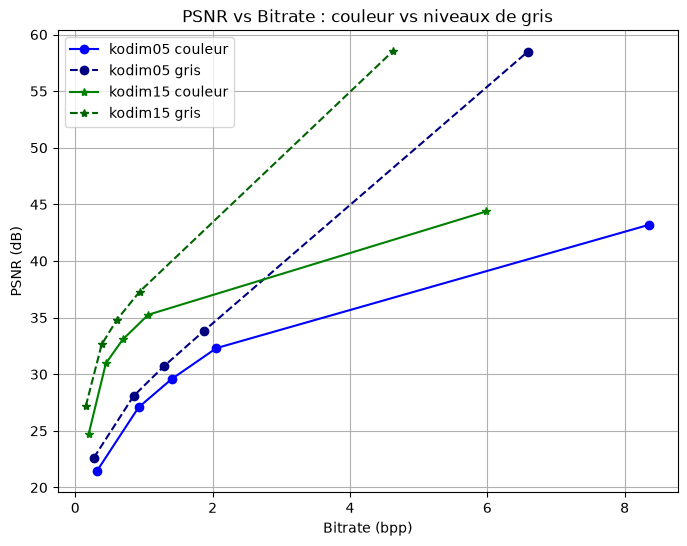

In [16]:
br_g1, ps_g1 = evaluer_jpeg("kodim05.png", gray=True, prefix="gris")
br_g2, ps_g2 = evaluer_jpeg("kodim15.png", gray=True, prefix="gris")

plt.figure(figsize=(8, 6))
plt.plot(bitrates1, psnr_values1, marker="o", linestyle="-",  color="blue",  label="kodim05 couleur")
plt.plot(br_g1,     ps_g1,        marker="o", linestyle="--", color="navy",  label="kodim05 gris")
plt.plot(bitrates2, psnr_values2, marker="*", linestyle="-",  color="green", label="kodim15 couleur")
plt.plot(br_g2,     ps_g2,        marker="*", linestyle="--", color="darkgreen", label="kodim15 gris")
plt.title("PSNR vs Bitrate : couleur vs niveaux de gris")
plt.xlabel("Bitrate (bpp)")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "bitrate_PSNR_couleur_vs_gris.png"), dpi=150)
plt.show()

### 4.5 Comparaison visuelle (q=5 vs q=100)

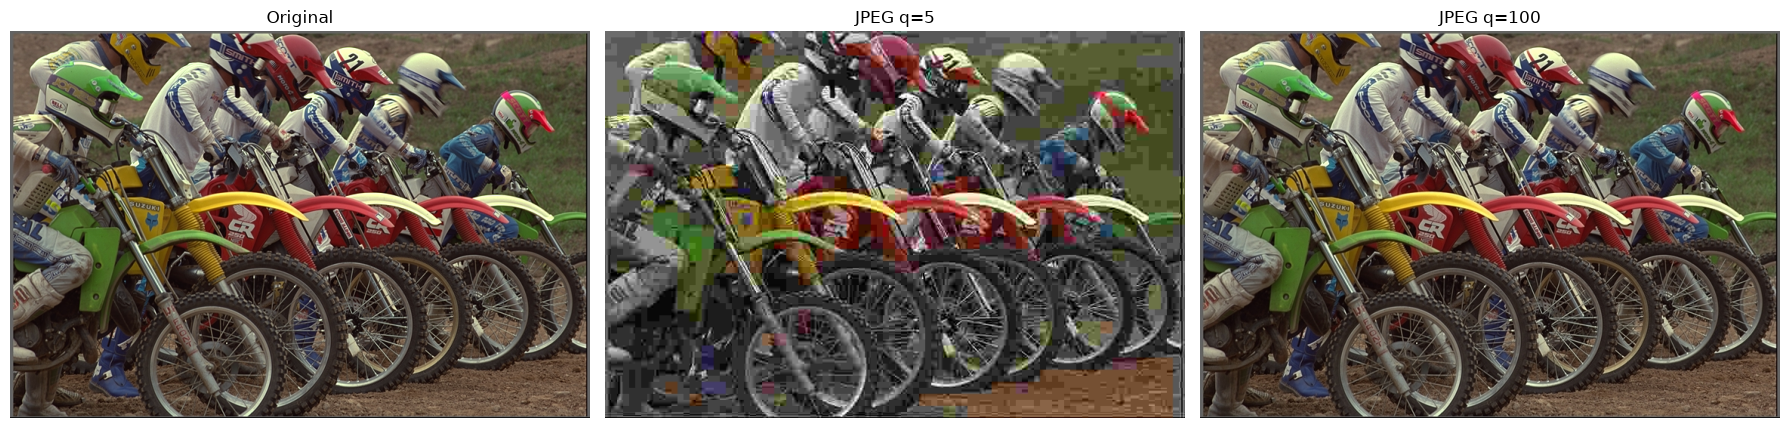

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(Image.open(os.path.join(DATA_DIR, "kodim05.png")).convert("RGB")); axes[0].set_title("Original")
axes[1].imshow(Image.open(os.path.join(OUT_DIR, "resultat_kodim05_q5.jpg")));     axes[1].set_title("JPEG q=5")
axes[2].imshow(Image.open(os.path.join(OUT_DIR, "resultat_kodim05_q100.jpg")));   axes[2].set_title("JPEG q=100")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()